
# ***ASSIGNMENT 10 : Comparing GAN and VAE Using Your Own Experimental Results***




###**Name:** Pragathi BR ###

###**Registration No.:** 2411021240037 ###

###**Course:** BCA (Artificial Intelligence & Machine Learning) — BCA AIML ###

###**Subject:** Generative AI ###

###**Date of Submission:** 08-10-2026 ###

###**Faculty Name**: Sanjivini Chowdhury ###

### **Objective**

The objective of this assignment is to compare a GAN and a VAE using the practical results obtained from previous experiments rather than only theoretical knowledge.

The comparison is based on:

- Image sharpness
- Diversity
- Realism
- Training stability
- Ease of controlling the output
- Risk of mode collapse
- Typical applications

The experimental results used in this assignment are:

- **Assignment 4:** Training a DCGAN on the Fashion-MNIST Dataset
- **Assignment 8:** Building a Variational Autoencoder and Visualising Its Latent Space

The final decision is also made for:
1. Synthetic training data generation
2. Anomaly detection

## **1. Experiments Used**

This experiment uses the results from my previously completed assignments.

### **GAN — Assignment 4**
- Model: DCGAN
- Dataset: Fashion-MNIST
- Image size: 28 × 28
- Image type: Grayscale
- Latent dimension: 100
- Generated output: Clothing-like Fashion-MNIST images

The Assignment 4 experiment saved generated image grids at different training stages. The generated images show how the Generator learned clothing-like patterns from random noise. :contentReference[oaicite:2]{index=2}

### **VAE — Assignment 8**
- Model: Variational Autoencoder
- Dataset: MNIST
- Latent representation: 2-dimensional
- Generated output: Digit-like MNIST images

The VAE generated images by sampling from its learned latent space.

## **2. Important Experimental Note**

The GAN and VAE were trained on different datasets.

- DCGAN → Fashion-MNIST clothing images
- VAE → MNIST handwritten digits

Therefore, this is not a strict image-quality benchmark between two models trained on the same data.

Instead, the comparison is based on the behaviour observed in my two experiments and on the characteristics demonstrated by their generated outputs.

In [42]:
# Upload the two previous assignment notebooks
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for name in uploaded.keys():
    print("-", name)

Saving Assignment_8_Variational_Autoencoder_MNIST.ipynb to Assignment_8_Variational_Autoencoder_MNIST (2).ipynb
Saving ASSIGNMENT_4_Training_a_DCGAN_on_the_Fashion_MNIST_Dataset.ipynb to ASSIGNMENT_4_Training_a_DCGAN_on_the_Fashion_MNIST_Dataset (2).ipynb
Uploaded files:
- Assignment_8_Variational_Autoencoder_MNIST (2).ipynb
- ASSIGNMENT_4_Training_a_DCGAN_on_the_Fashion_MNIST_Dataset (2).ipynb


In [43]:
import json
import os
import base64
from IPython.display import display, Image

# Find uploaded notebook names automatically
notebooks = [f for f in uploaded.keys() if f.endswith(".ipynb")]

print("Notebook files found:")
for f in notebooks:
    print(f)

Notebook files found:
Assignment_8_Variational_Autoencoder_MNIST (2).ipynb
ASSIGNMENT_4_Training_a_DCGAN_on_the_Fashion_MNIST_Dataset (2).ipynb


In [44]:
def load_notebook(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

gan_file = [f for f in notebooks if "Assignment_4" in f or "DCGAN" in f][0]
vae_file = [f for f in notebooks if "Assignment_8" in f or "VAE" in f][0]

gan_nb = load_notebook(gan_file)
vae_nb = load_notebook(vae_file)

print("GAN notebook:", gan_file)
print("VAE notebook:", vae_file)

GAN notebook: ASSIGNMENT_4_Training_a_DCGAN_on_the_Fashion_MNIST_Dataset (2).ipynb
VAE notebook: Assignment_8_Variational_Autoencoder_MNIST (2).ipynb


## **3. GAN Generated Results**

The DCGAN experiment produced 4 × 4 image grids at different checkpoints during training.

For this comparison, the generated images are taken from the existing Assignment 4 notebook output rather than training the model again.

In [53]:
# Find image outputs from the GAN notebook

gan_image_outputs = []

for cell_no, cell in enumerate(gan_nb["cells"]):
    if cell.get("cell_type") != "code":
        continue

    source = "".join(cell.get("source", [])).lower()

    # Focus on generated-image related cells
    keywords = [
        "generated",
        "save_image",
        "saved_images",
        "fixed_noise"
    ]

    if any(k in source for k in keywords):
        for output in cell.get("outputs", []):
            if "data" in output and "image/png" in output["data"]:
                gan_image_outputs.append({
                    "cell": cell_no,
                    "image": output["data"]["image/png"],
                    "source": source
                })

print("Generated-image outputs found:", len(gan_image_outputs))

Generated-image outputs found: 9



GAN generated output 1 — notebook cell 28


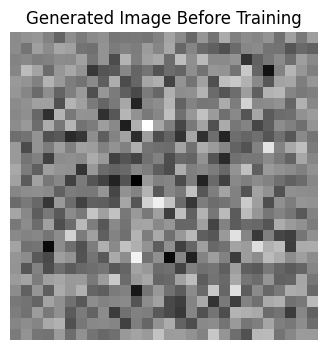


GAN generated output 2 — notebook cell 50


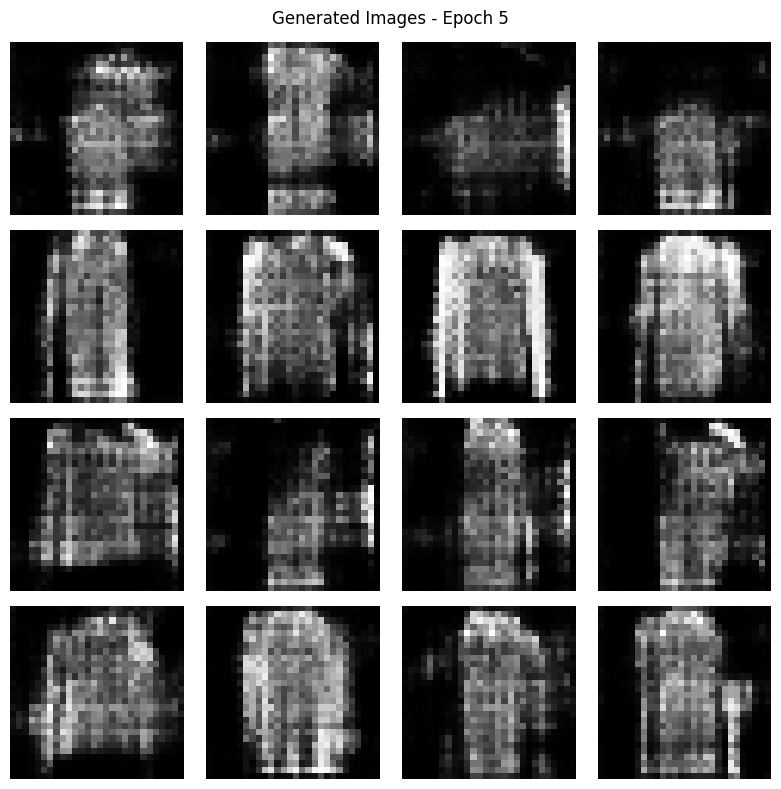


GAN generated output 3 — notebook cell 50


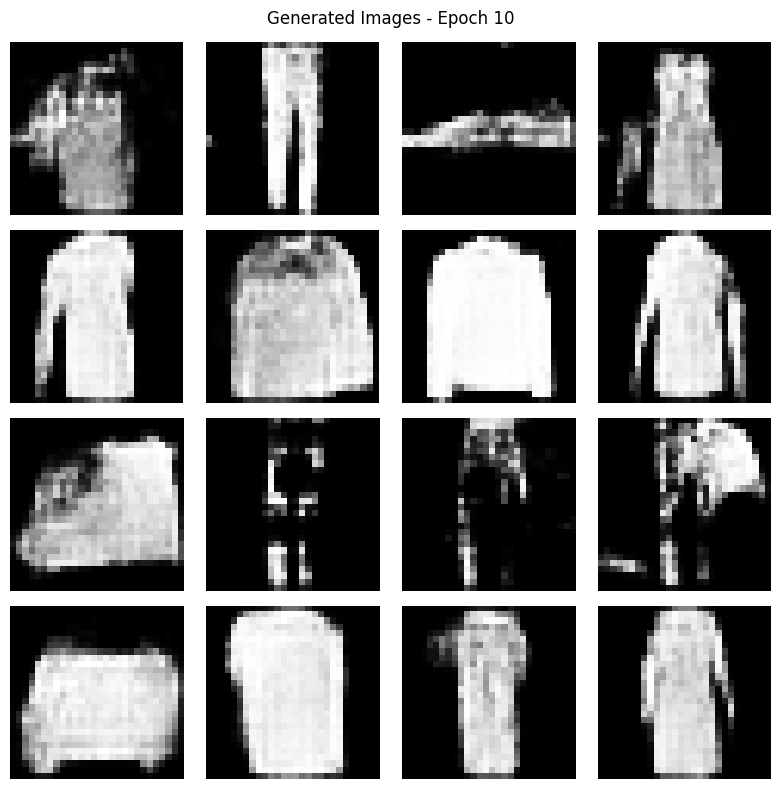


GAN generated output 4 — notebook cell 50


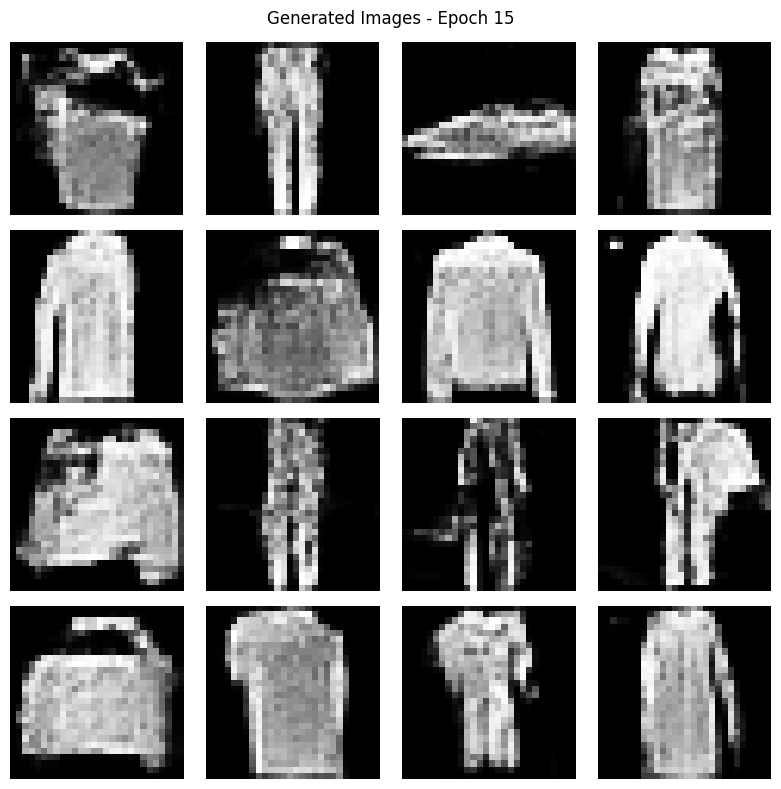


GAN generated output 5 — notebook cell 50


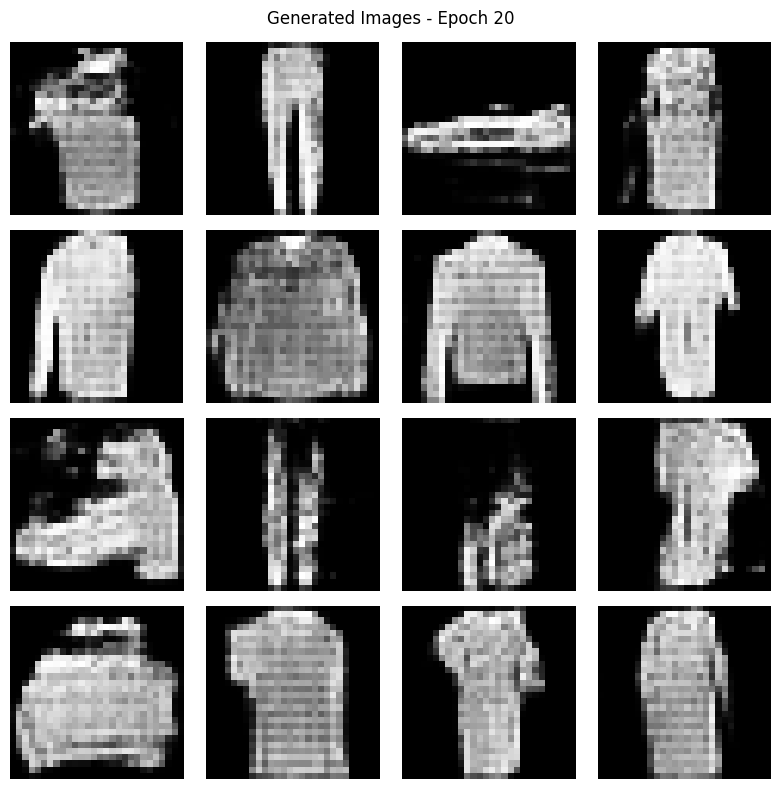


GAN generated output 6 — notebook cell 50


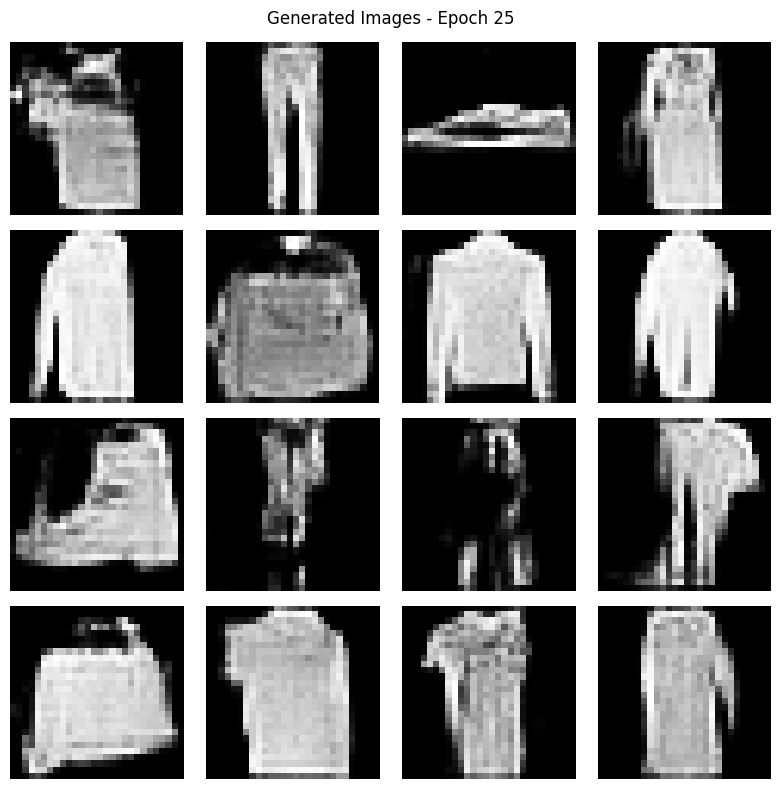


GAN generated output 7 — notebook cell 50


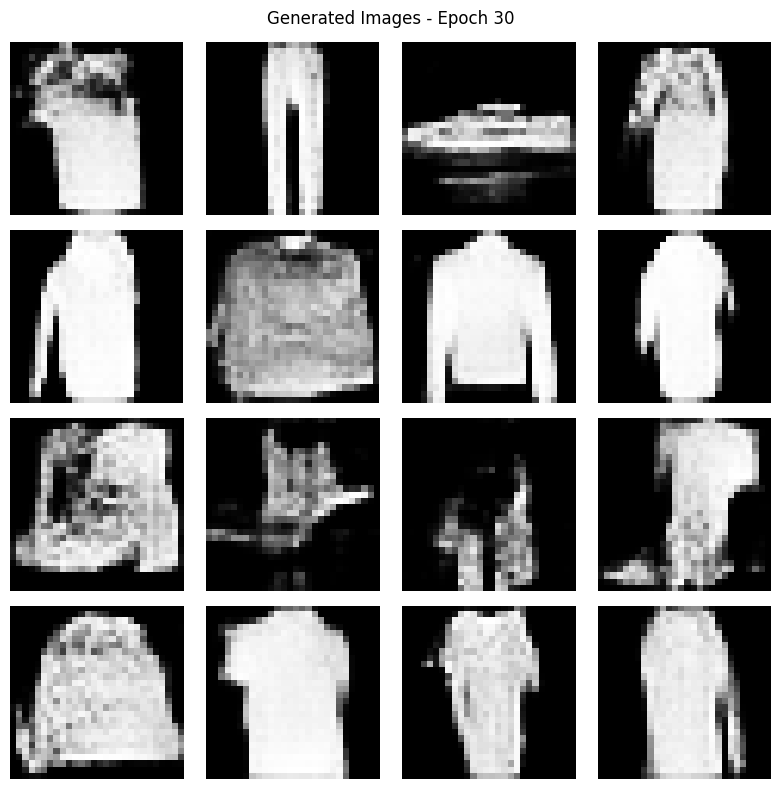


GAN generated output 8 — notebook cell 55


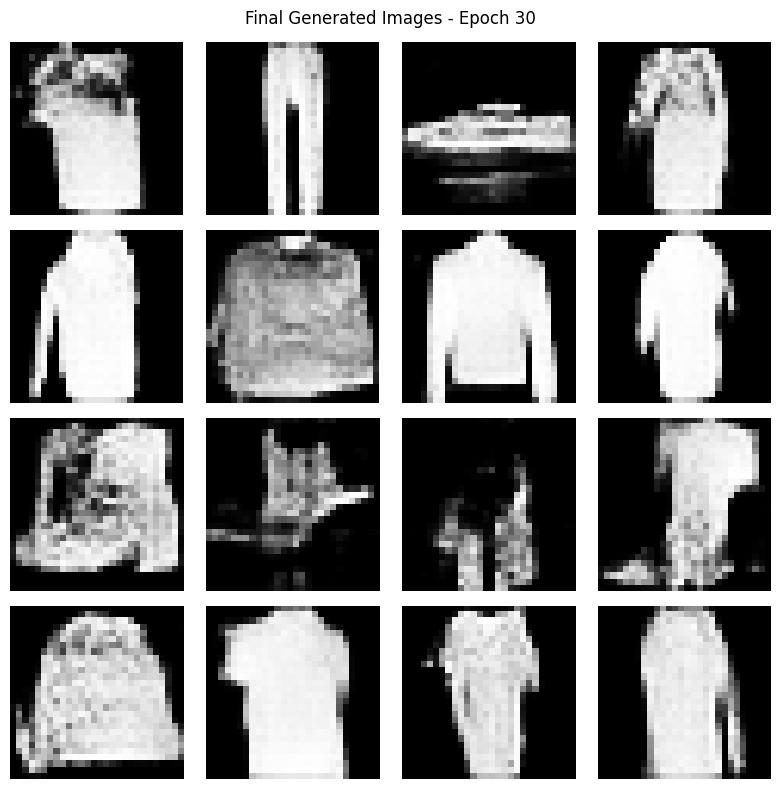


GAN generated output 9 — notebook cell 57


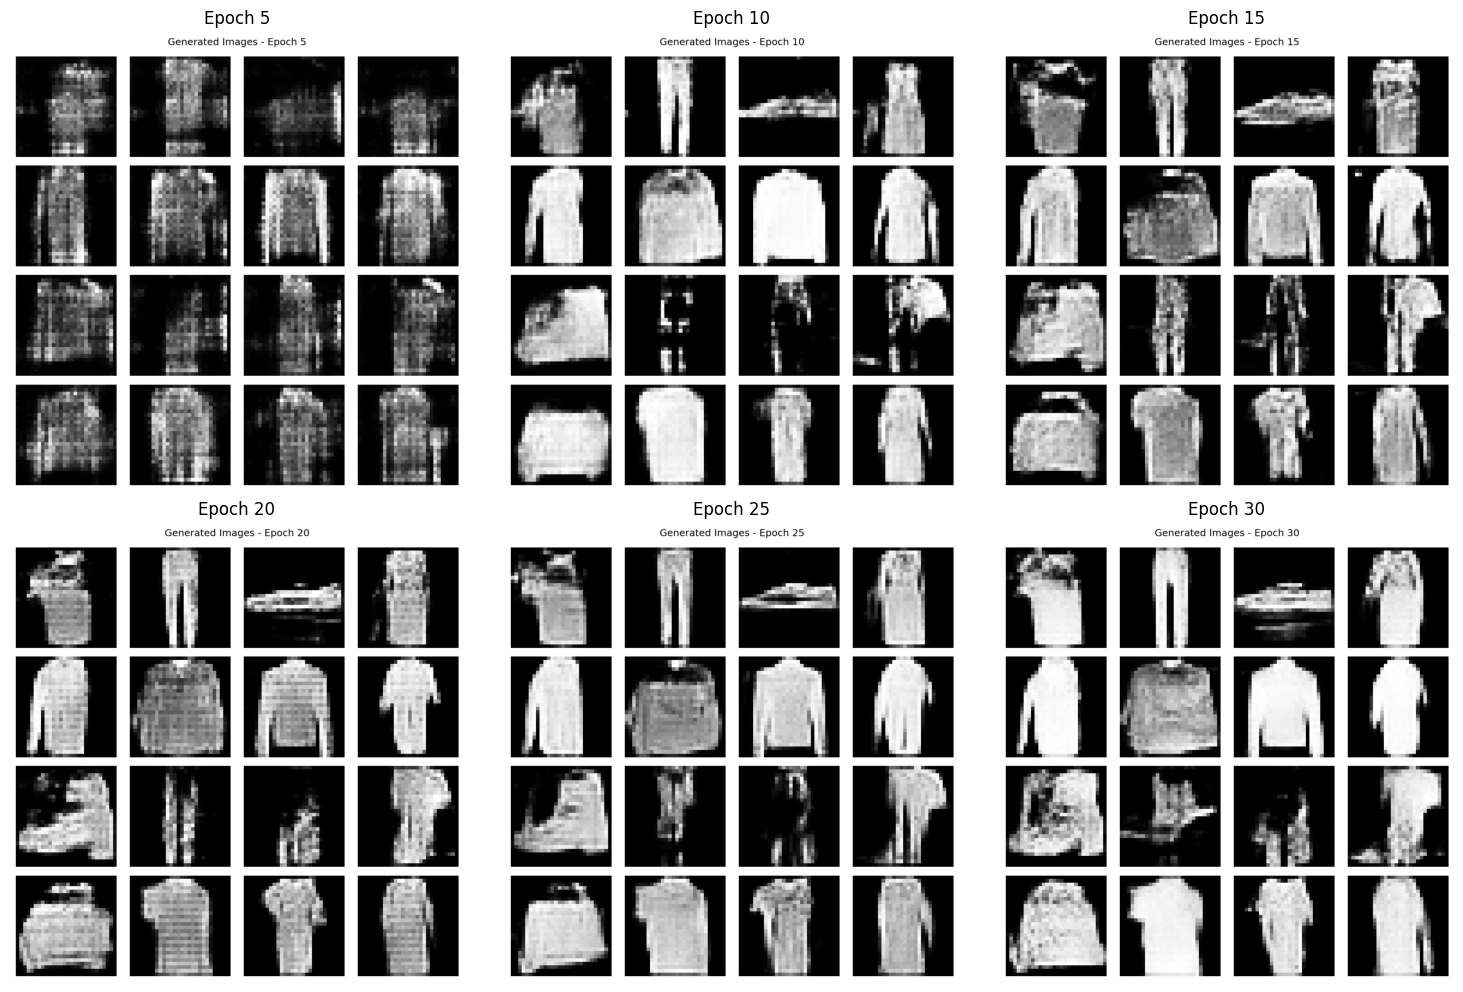

In [52]:
# Display GAN image outputs only
# Graphs are intentionally excluded.

for i, item in enumerate(gan_image_outputs):
    print(f"\nGAN generated output {i+1} — notebook cell {item['cell']}")

    img_bytes = base64.b64decode(item["image"])
    display(Image(data=img_bytes))

## **4. Eight Representative GAN-Generated Samples**

The following section uses representative samples from the generated Fashion-MNIST output.

These are not newly generated images. They are selected from the existing output of Assignment 4 so that the original experiment remains unchanged.

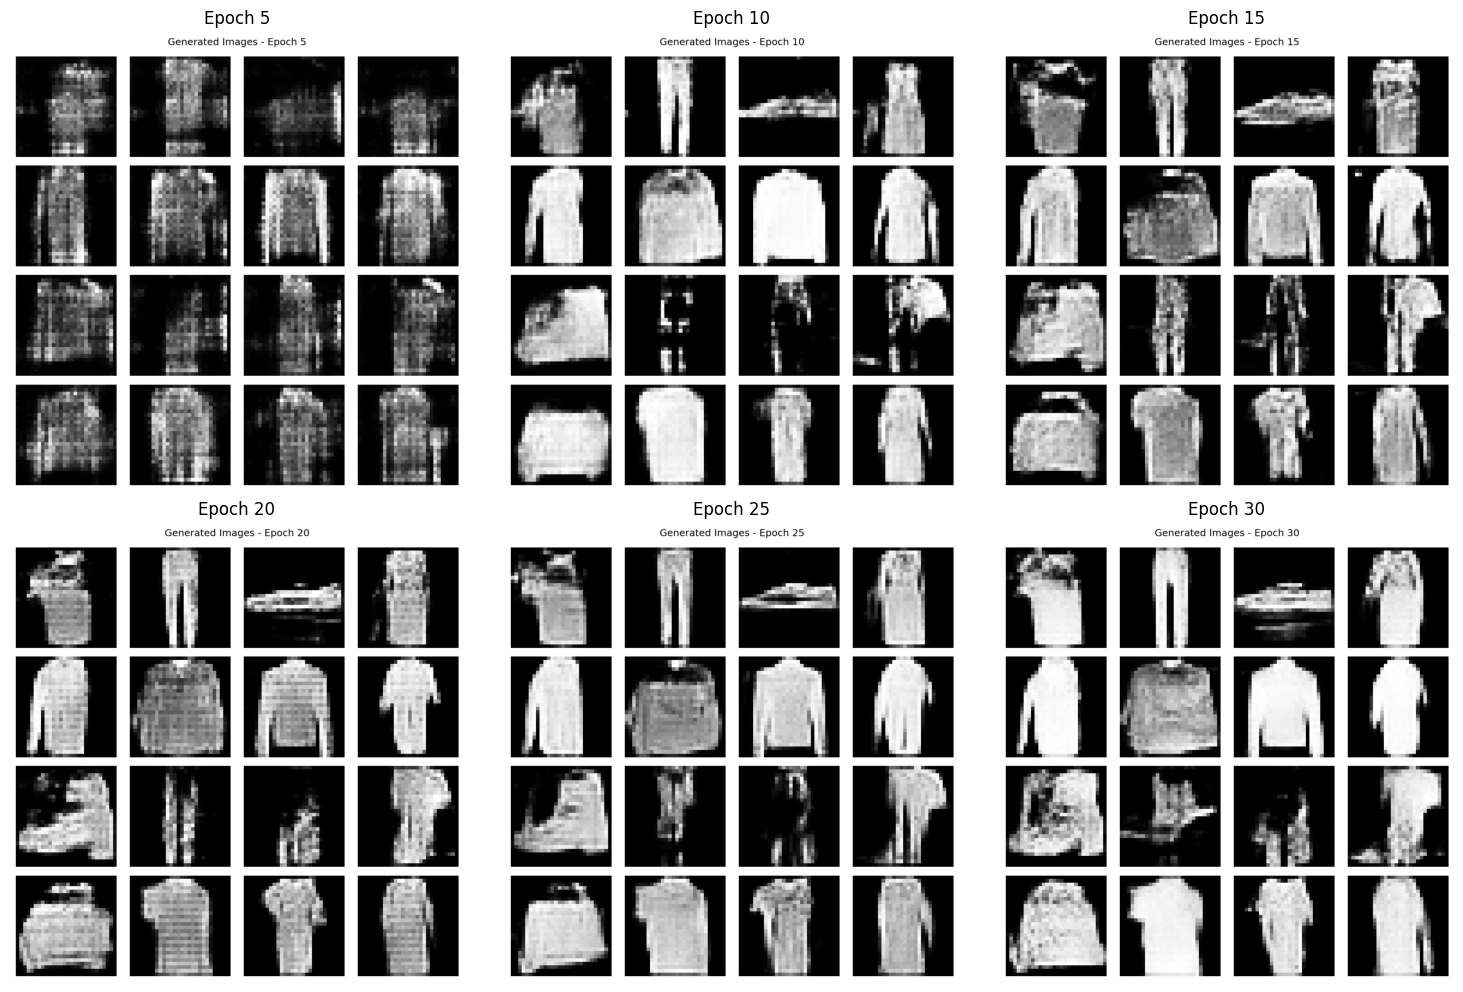

In [47]:
# Select the final GAN generated grid
# The latest generated-image output is treated as the final result.

gan_final = gan_image_outputs[-1]["image"]

gan_bytes = base64.b64decode(gan_final)

display(Image(data=gan_bytes))

### **GAN Observation**

The generated samples contain clothing-like structures such as footwear, tops and other Fashion-MNIST patterns. The images are recognizable at the overall shape level, although some samples may contain rough edges or incomplete details.

The main strength observed from the GAN experiment is its ability to create visually structured samples directly from random noise.

## **5. VAE Generated Results**

The VAE experiment generated digit images by exploring its learned 2-dimensional latent space.

The generated output is taken directly from Assignment 8. No additional VAE training is performed in this assignment.

In [68]:
# Search for the VAE generated-image output.
# We specifically look for the latent-space digit generation section.

vae_image_outputs = []

for cell_no, cell in enumerate(vae_nb["cells"]):
    if cell.get("cell_type") != "code":
        continue

    source = "".join(cell.get("source", []))

    keywords = [
        "digits generated",
        "latent space",
        "generated"
    ]

    if any(k.lower() in source.lower() for k in keywords):
        for output in cell.get("outputs", []):
            if "data" in output and "image/png" in output["data"]:
                vae_image_outputs.append({
                    "cell": cell_no,
                    "image": output["data"]["image/png"],
                    "source": source
                })

print("VAE generated-image outputs found:", len(vae_image_outputs))

VAE generated-image outputs found: 3


Original VAE Generated Image:


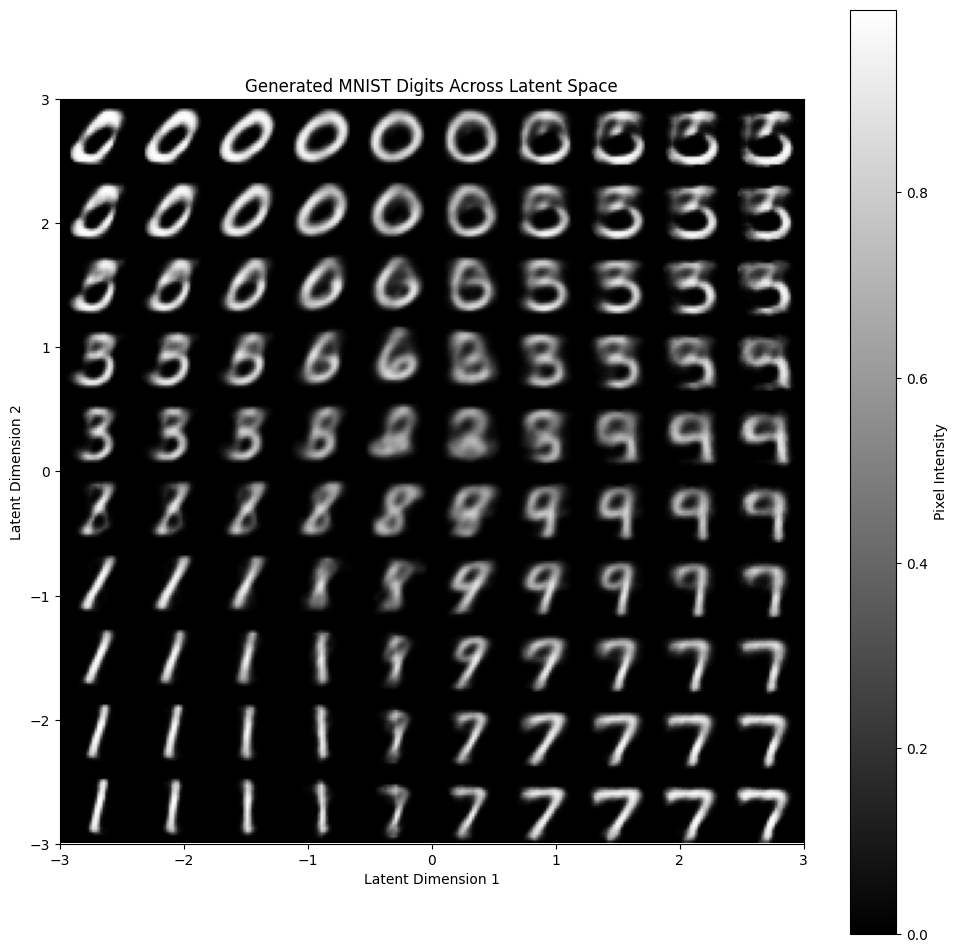

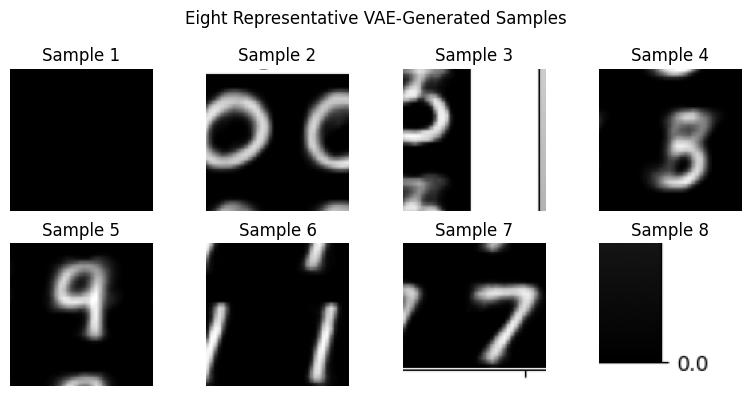

In [69]:
# Display 8 representative VAE-generated samples

from PIL import Image as PILImage
from IPython.display import display
import base64
import io
import numpy as np
import matplotlib.pyplot as plt

# Get the final VAE-generated image
vae_final = vae_image_outputs[-1]["image"]

# Decode the image
img_bytes = base64.b64decode(vae_final)
vae_img = PILImage.open(io.BytesIO(img_bytes)).convert("L")

# Display original generated grid
print("Original VAE Generated Image:")
display(vae_img)

# Convert to NumPy array
vae_array = np.array(vae_img)

# VAE output contains a 10 × 10 generated grid
rows = 10
cols = 10

cell_h = vae_array.shape[0] // rows
cell_w = vae_array.shape[1] // cols

# Select 8 representative positions
selected_positions = [
    (0, 0),
    (1, 4),
    (2, 8),
    (4, 2),
    (5, 6),
    (7, 1),
    (8, 5),
    (9, 9)
]

# Display exactly 8 samples
fig, axes = plt.subplots(2, 4, figsize=(8, 4))

for i, (ax, (r, c)) in enumerate(
    zip(axes.flatten(), selected_positions), start=1
):
    y1 = r * cell_h
    y2 = (r + 1) * cell_h

    x1 = c * cell_w
    x2 = (c + 1) * cell_w

    sample = vae_array[y1:y2, x1:x2]

    ax.imshow(sample, cmap="gray")
    ax.set_title(f"Sample {i}")
    ax.axis("off")

plt.suptitle("Eight Representative VAE-Generated Samples")
plt.tight_layout()
plt.show()

## **6. Representative VAE Samples**

The displayed VAE result represents the generated digits obtained by sampling across the learned 2-dimensional latent space.

The samples show variation in digit shape and writing style. Some generated digits have softer boundaries because the VAE reconstructs and generates images through a probabilistic latent representation.

## **7. Practical Comparison**

The following comparison is based on the outputs and behaviour observed in my two experiments.

| Comparison Factor | DCGAN – Assignment 4 | VAE – Assignment 8 |
|---|---|---|
| **Image Sharpness** | Generated clothing structures are comparatively defined, although some edges are rough. | Generated digits are smoother and may have softer boundaries. |
| **Diversity** | Produces different clothing-like patterns from different noise vectors. | The 2D latent space provides different digit variations across locations. |
| **Realism** | The samples can resemble Fashion-MNIST clothing categories at a visual level. | The samples resemble handwritten digits, although some may look smooth or incomplete. |
| **Training Stability** | Training is more difficult because Generator and Discriminator continuously compete. | Training is generally more predictable because reconstruction and KL objectives are optimized together. |
| **Ease of Control** | The 100-dimensional noise vector is difficult to interpret directly. | The 2-dimensional latent space is easier to visualize and explore. |
| **Mode Collapse Risk** | GANs can suffer from mode collapse if the Generator repeatedly produces limited types of samples. | VAE does not have the same adversarial mode-collapse problem. |
| **Typical Applications** | Synthetic image generation and data augmentation. | Reconstruction, representation learning, latent-space exploration and anomaly detection. |

## **8. What I Observed From My Experiments**

### **DCGAN**

The DCGAN learned to convert random noise into Fashion-MNIST-like clothing images. As training progressed, the Generator learned more meaningful shapes and structures.

However, adversarial training can be difficult to stabilize because the Generator and Discriminator are continuously competing with each other.

### **VAE**

The VAE learned a continuous 2-dimensional latent representation. This makes the latent space easier to visualize and understand.

The generated digits are generally smooth because the VAE learns to reconstruct the input while also regularizing its latent representation.

## **9. Final Decision**

### **1. Which model is better for generating synthetic training data?**

**Decision: GAN**

I would select the GAN for synthetic image generation because the generated samples can have clearer and more realistic-looking structures. This makes GANs useful when the main requirement is to create additional image-like training samples.

From my Assignment 4 experiment, the DCGAN was able to generate recognizable Fashion-MNIST-like clothing patterns from random noise.

### **2. Which model is better for anomaly detection?**

**Decision: VAE**

I would select the VAE for anomaly detection because it learns an encoder-decoder representation of the data. An input can be reconstructed, and unusual samples can be identified when their reconstruction behaviour differs significantly from normal samples.

The 2-dimensional latent representation in my Assignment 8 experiment also makes the learned representation easier to inspect.

**Important:** Anomaly detection itself was not directly implemented and measured in Assignment 8. Therefore, this is a model-selection decision based on the VAE's reconstruction and latent-space properties rather than a measured anomaly-detection accuracy.

## **Why These Models Were Selected**

The GAN is selected for synthetic training data because its generated samples are relatively sharp and realistic-looking.

The VAE is selected for anomaly detection because it learns a structured latent representation and provides reconstruction capability.

The final decision is based on the experimental outputs obtained from Assignment 4 and Assignment 8.

## **10. Conclusion**

The experiments helped me understand the practical difference between GAN-based and VAE-based generation.

The DCGAN was more suitable when the goal was to generate visually structured synthetic images, while the VAE provided a more organized latent representation and reconstruction-based learning.

Therefore:

- **Synthetic training data → GAN**
- **Anomaly detection → VAE**

The comparison also showed that GANs can provide sharper-looking outputs but may be harder to stabilize, whereas VAEs provide a smoother and more interpretable latent representation.